# Import Libraries

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import missingno as msno
from imblearn .over_sampling import SMOTE

import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix , f1_score


In [2]:
diabetes_df = pd.read_csv('../input/pima-indians-diabetes-database/diabetes.csv')
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
print(diabetes_df.shape)

(768, 9)


## Get a statsistics insights and deep inforamtion about our dataset

In [4]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
diabetes_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


*Note: The min value for "Glucose , BloodPressure , SkinThickness , Insulin and BMI" is 0 
which is not logic value for such features*
#### so we should deal with it , by Replacing the 0 value with null

## Replacing the unlogically value (0) with null

In [6]:

diabetes_df.loc[:,'Glucose'].replace(0 , np.NaN , inplace=True)
diabetes_df.loc[:,'BloodPressure'].replace(0 , np.NaN , inplace=True)
diabetes_df.loc[:,'SkinThickness'].replace(0 , np.NaN , inplace=True)
diabetes_df.loc[:,'BMI'].replace(0 , np.NaN , inplace=True)



## Check the null values

In [7]:
diabetes_df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                       0
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [8]:
diabetes_df.isnull().value_counts()

Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin  BMI    DiabetesPedigreeFunction  Age    Outcome
False        False    False          False          False    False  False                     False  False      532
                                     True           False    False  False                     False  False      192
                      True           True           False    False  False                     False  False       26
                                                             True   False                     False  False        7
             True     False          False          False    False  False                     False  False        5
             False    True           False          False    False  False                     False  False        2
                      False          True           False    True   False                     False  False        2
                                     False          False    True   False      

<Figure size 216x216 with 0 Axes>

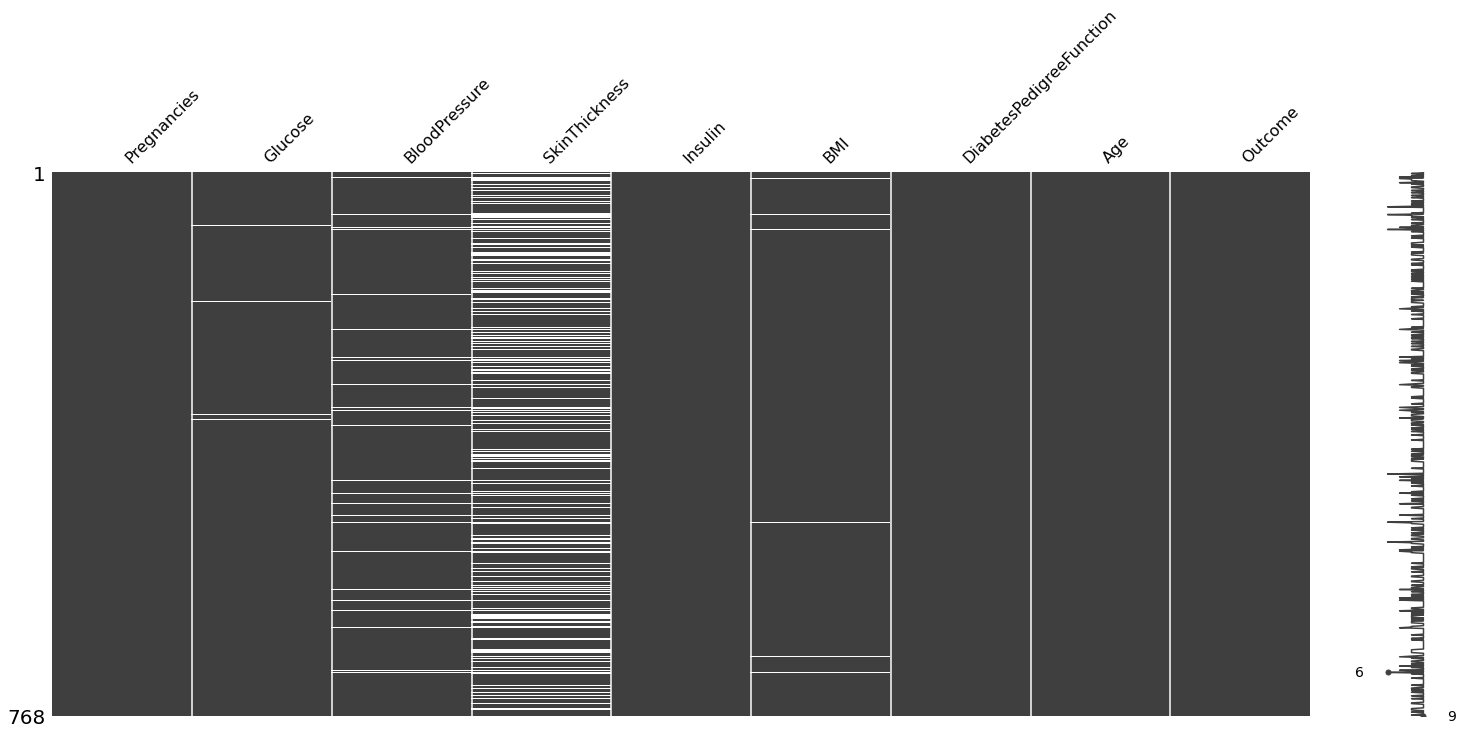

In [9]:
plt.figure(figsize=(3,3))
msno.matrix(diabetes_df)
plt.show()

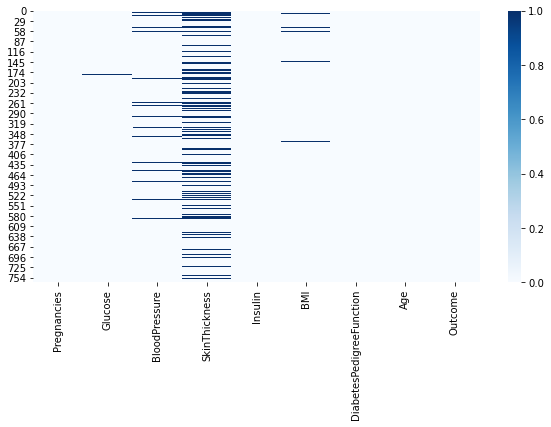

In [10]:
plt.figure(figsize=(10,5))
sns.heatmap(diabetes_df.isna() , cmap='Blues')
plt.show()

## dealing with the null values

In [11]:
diabetes_df.loc[:,'Glucose'].fillna(diabetes_df.loc[:,'Glucose'].mean(),inplace=True)
diabetes_df.loc[:,'BloodPressure'].fillna(diabetes_df.loc[:,'BloodPressure'].mean(),inplace=True)
diabetes_df.loc[:,'SkinThickness'].fillna(diabetes_df.loc[:,'SkinThickness'].mean(),inplace=True)
diabetes_df.loc[:,'BMI'].fillna(diabetes_df.loc[:,'BMI'].mean(),inplace=True)

In [12]:
diabetes_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.00000,0,33.6,0.627,50,1
1,1,85.0,66.0,29.00000,0,26.6,0.351,31,0
2,8,183.0,64.0,29.15342,0,23.3,0.672,32,1
3,1,89.0,66.0,23.00000,94,28.1,0.167,21,0
4,0,137.0,40.0,35.00000,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.00000,180,32.9,0.171,63,0
764,2,122.0,70.0,27.00000,0,36.8,0.340,27,0
765,5,121.0,72.0,23.00000,112,26.2,0.245,30,0
766,1,126.0,60.0,29.15342,0,30.1,0.349,47,1


# Check imbalnce dataset

In [13]:
diabetes_df['Outcome'].value_counts()

0    500
1    268
Name: Outcome, dtype: int64

> Note: Our data set is imbalnced as the count of diabetic is consided half the non diabetic 

## Visualizing the count of class_label

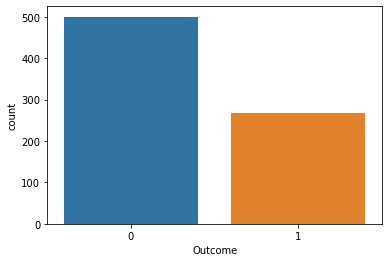

In [14]:
sns.countplot(data = diabetes_df , x='Outcome')

In [15]:
plt.figure(figsize=(10,5))
col = ['non diabetics','diabetics']
px.pie(diabetes_df , values=diabetes_df['Outcome'].value_counts(),names=col,
       color_discrete_sequence=px.colors.sequential.RdBu)

<Figure size 720x360 with 0 Axes>

## Dealing with the imbalance dataset

# Get the features and class label

In [16]:
X = diabetes_df.drop('Outcome',axis=1)
y = diabetes_df['Outcome']


# Preprocessing Our Dataset Using StandardScaler 

In [17]:
X_scaler = StandardScaler().fit_transform(X)

# Splitting the dataset to training(80%)and testing (20%)set

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X_scaler,y,random_state=0,test_size=0.20)

print('The shape of X_train:'+' '+str(X_train.shape))
print('The size of X_train:'+' '+str(X_train.shape[0]))
print('The shape of X_test:'+' '+str(X_test.shape))
print('The size of X_test:'+' '+str(X_test.shape[0]))

The shape of X_train: (614, 8)
The size of X_train: 614
The shape of X_test: (154, 8)
The size of X_test: 154


# Training our dataset via Model

## KNN model

In [23]:
knn_clf = KNeighborsClassifier(n_neighbors=10).fit(X_train , y_train)
knn_clf.score(X_train , y_train)

0.7931596091205212

In [24]:
pred = knn_clf.predict(X_test)
print(accuracy_score(y_true=y_test , y_pred=pred))

0.8116883116883117


### Note our data set is imbalnce , so the best performance evaluation is f1_score

In [26]:
target_name = []
classification_report(y_true=y_test , y_pred=pred,output_dict=True)


{'0': {'precision': 0.8305084745762712,
  'recall': 0.9158878504672897,
  'f1-score': 0.8711111111111112,
  'support': 107},
 '1': {'precision': 0.75,
  'recall': 0.574468085106383,
  'f1-score': 0.6506024096385542,
  'support': 47},
 'accuracy': 0.8116883116883117,
 'macro avg': {'precision': 0.7902542372881356,
  'recall': 0.7451779677868364,
  'f1-score': 0.7608567603748326,
  'support': 154},
 'weighted avg': {'precision': 0.8059377063614352,
  'recall': 0.8116883116883117,
  'f1-score': 0.8038130009214346,
  'support': 154}}